In [43]:
from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing
import matplotlib.pyplot as plt
import muon as mu

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
DEV_DIR = str(Path(PROJECT_DIR) / "dev")
if DEV_DIR not in sys.path:
    sys.path.insert(0, DEV_DIR)
    
import muon_preprocessing as muon_prep

In [44]:
PROJECT_DIR=Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")
DATA_DIR=Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

STABILITY_CELL_SUBSAMPLE_DIR=Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/STABILITY_RAW_DATASETS")

DATASET_NAME="K562_10x_raw"
SAMPLE_NAME="sample_1"
PROCESSED_DATA_NAME=f"K562_{SAMPLE_NAME}_test_peaks_conv_only"
ORGANISM_CODE="hg38"

TSS_PATH=f"{PROJECT_DIR}/data/genome_data/genome_annotation/{ORGANISM_CODE}/gene_tss.bed"
TF_LIST_FILE=""

RAW_DATA_DIR=f"{DATA_DIR}/RAW_DATA/{DATASET_NAME}"
PROCESSED_DATA_DIR=f"{DATA_DIR}/PROCESSED_DATA/{PROCESSED_DATA_NAME}"

FRAG_PATH=f"{RAW_DATA_DIR}/{SAMPLE_NAME}/fragments.sorted.tsv.gz"

RNA_COUNT_FILE=""
ATAC_COUNT_FILE=""

RAW_H5_FILE=""

SAMPLE_DATA_DIR = Path(RAW_DATA_DIR) / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = Path(PROCESSED_DATA_DIR) / SAMPLE_NAME

In [45]:
tss_path = Path(TSS_PATH)
rna_count_file = Path(RNA_COUNT_FILE) if RNA_COUNT_FILE else None
atac_count_file = Path(ATAC_COUNT_FILE) if ATAC_COUNT_FILE else None
raw_h5_file = Path(RAW_H5_FILE) if RAW_H5_FILE else None
tf_list_file = Path(TF_LIST_FILE) if TF_LIST_FILE else None
frag_path = Path(FRAG_PATH) if FRAG_PATH else None

In [46]:
filtering_setting_df = pd.read_csv(PROJECT_DIR / "dev" / "notebooks" / "muon_preprocessing" /"qc_filtering_settings.tsv", sep="\t")
sample_filtering_settings = filtering_setting_df[filtering_setting_df["Sample"] == SAMPLE_NAME]    

# ----- RNA QC thresholds -----
MIN_CELLS_PER_GENE = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Gene")
MIN_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Genes per Cell")
MAX_GENES_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Genes per Cell")
MIN_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Counts")
MAX_TOTAL_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Counts")
MAX_PCT_COUNTS_MT = muon_prep.get_threshold(sample_filtering_settings, "Max Pct MT")

# ----- ATAC QC thresholds -----
MIN_CELLS_PER_PEAK = muon_prep.get_threshold(sample_filtering_settings, "Min Cells per Peak")
MIN_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Min Peaks per Cell")
MAX_PEAKS_PER_CELL = muon_prep.get_threshold(sample_filtering_settings, "Max Peaks per Cell")
MIN_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Min Total Peak Counts")
MAX_TOTAL_PEAK_COUNTS = muon_prep.get_threshold(sample_filtering_settings, "Max Total Peak Counts")

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

Min Cells per Gene: 3
Min Genes per Cell: 1000
Max Genes per Cell: 10000
Min Total Counts: 500
Max Total Counts: 50000
Max Pct MT: 20
Min Cells per Peak: 1
Min Peaks per Cell: 100
Max Peaks per Cell: 20000
Min Total Peak Counts: 1000
Max Total Peak Counts: 50000


In [47]:
mdata, frag_path = muon_prep.load_raw_data(SAMPLE_NAME, SAMPLE_DATA_DIR, rna_count_file, atac_count_file, raw_h5_file)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

Loading data for sample sample_1 from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/K562_10x_raw/sample_1...
  - fragments.tsv.gz.tbi
  - features.tsv.gz
  - fragments.tsv.gz
  - barcodes.tsv.gz
  - matrix.mtx.gz
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical
... storing 'feature_types' as categorical


In [48]:
import importlib
importlib.reload(muon_prep)

<module 'muon_preprocessing' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/muon_preprocessing.py'>

In [49]:
data_processor = muon_prep.MudataProcessor(
    mdata=mdata,
    processed_data_dir=SAMPLE_PROCESSED_DATA_DIR,
    sample_name=SAMPLE_NAME,
    tss_path=tss_path,
    tf_list_file=tf_list_file
)

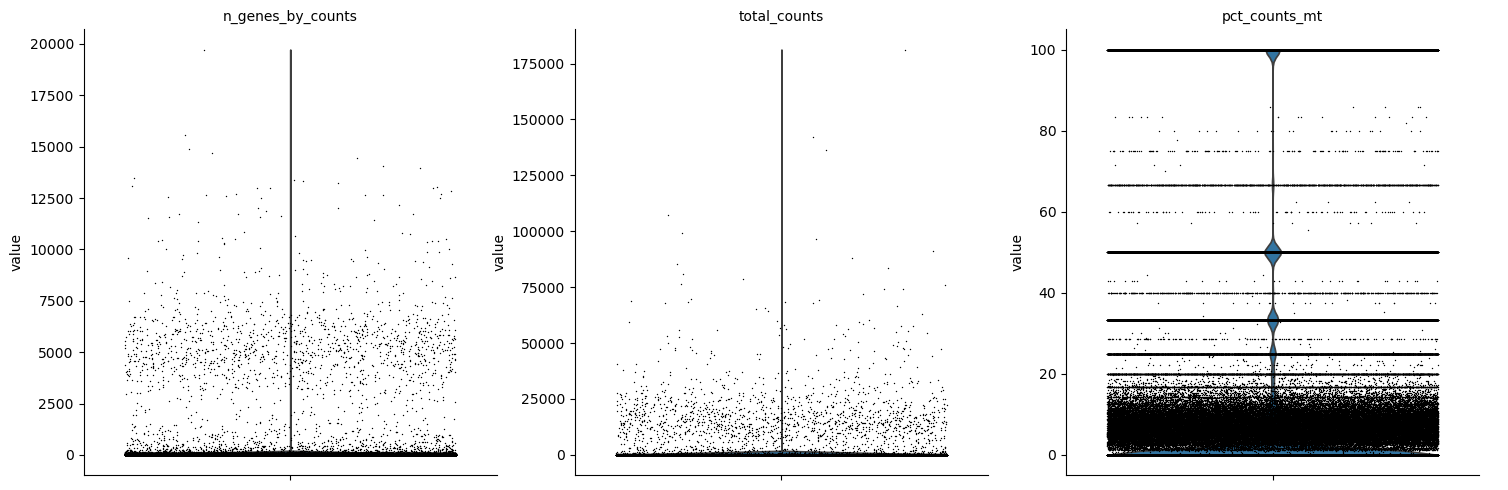

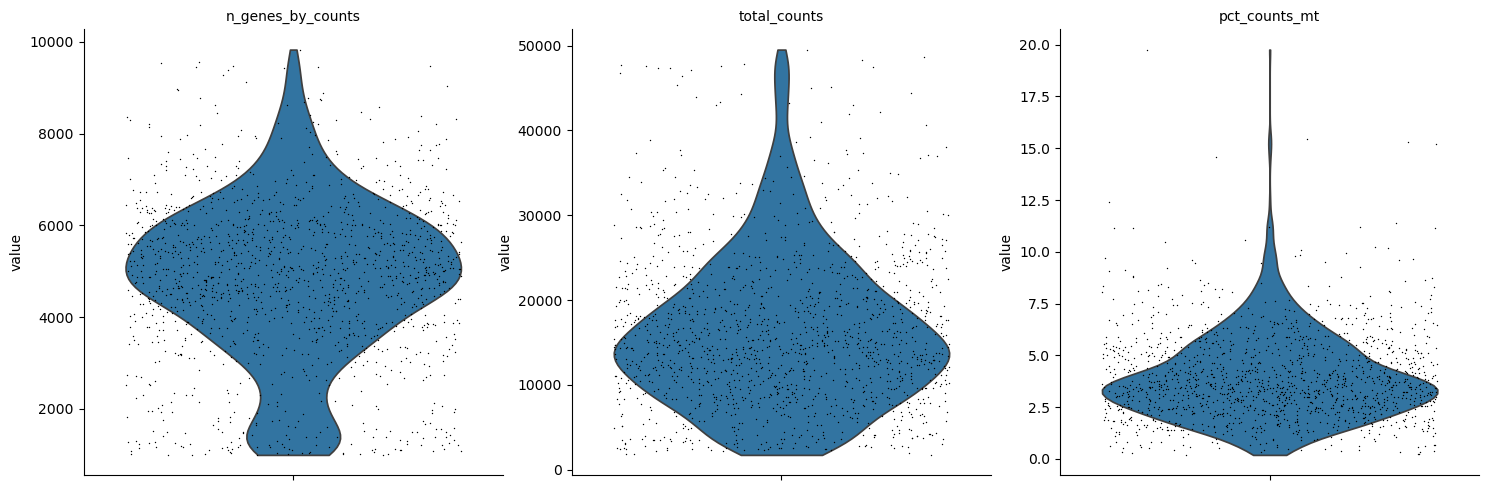

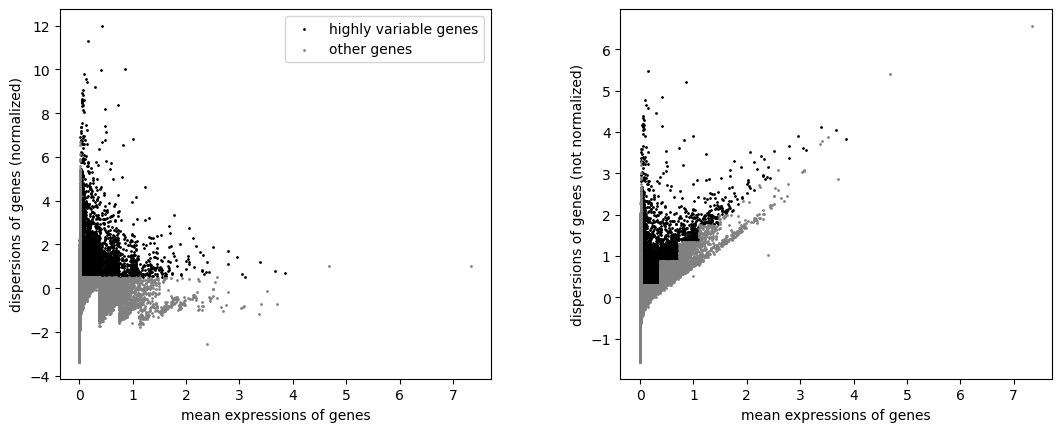

In [50]:
# RNA QC and Preprocessing
data_processor.rna_qc_filter(
    min_cells_per_gene = MIN_CELLS_PER_GENE,
    min_genes_per_cell = MIN_GENES_PER_CELL,
    max_genes_per_cell = MAX_GENES_PER_CELL,
    min_total_counts_per_cell = MIN_TOTAL_COUNTS,
    max_total_counts_per_cell = MAX_TOTAL_COUNTS,
    max_pct_counts_mt = MAX_PCT_COUNTS_MT,
    norm_target_sum = 1e4,
    min_rna_disp = 0.5,
    filter_hvgs = True,
    tf_list_file = None,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

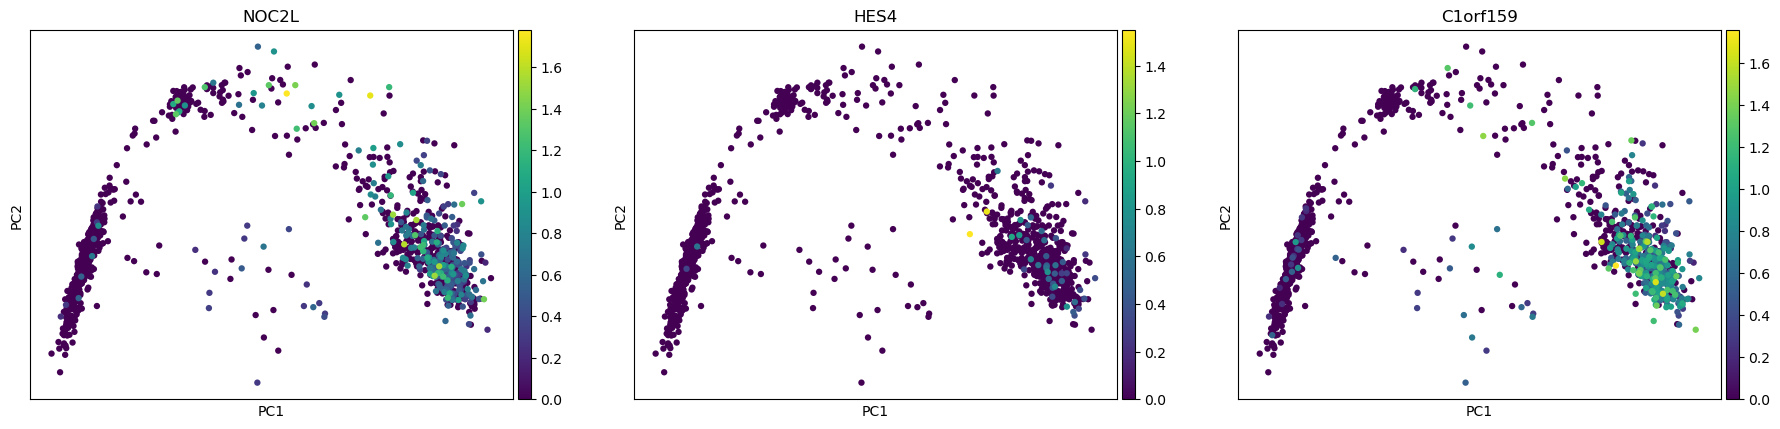

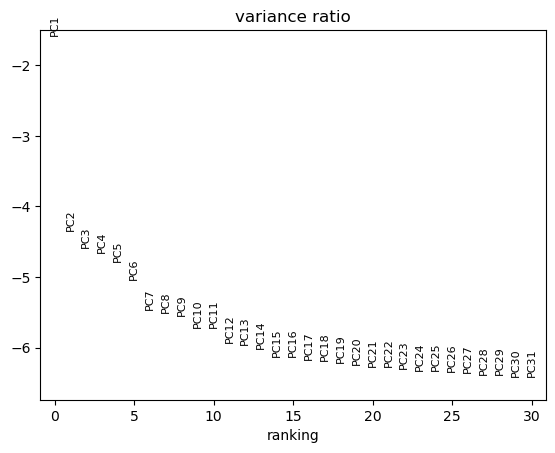

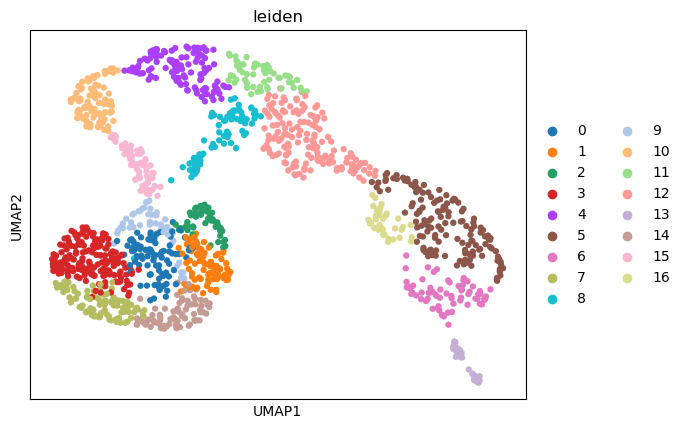

In [51]:
data_processor.rna_pca_and_neighbors(
    data_processor.rna, 
    n_pcs=6,
    n_neighbors=10,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "rna_qc",
    )

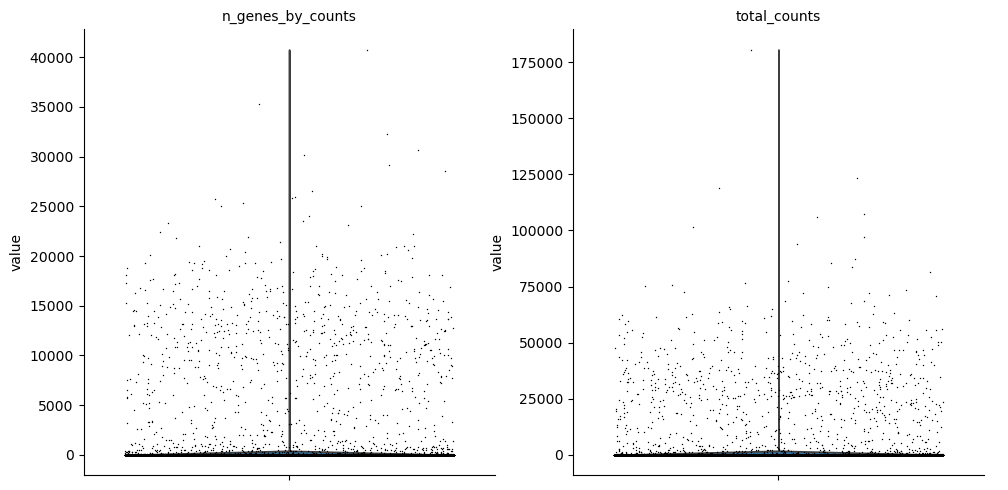

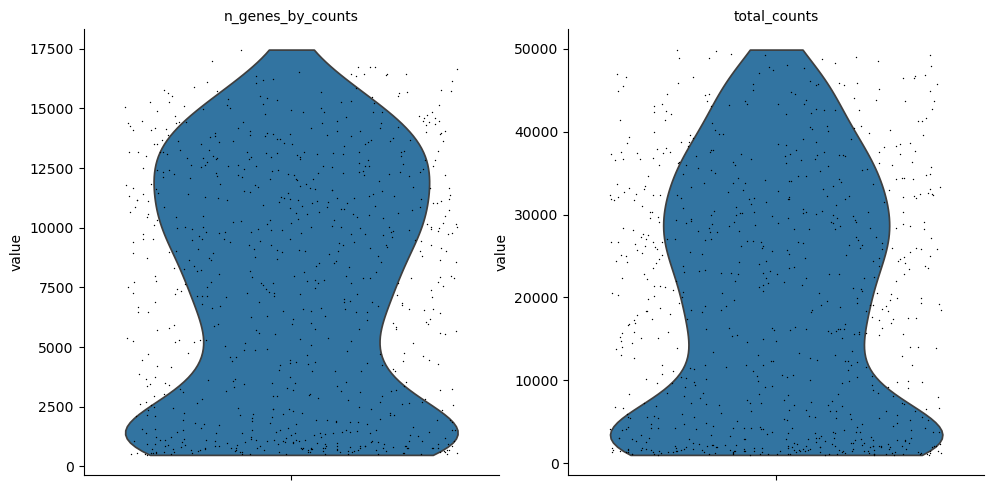

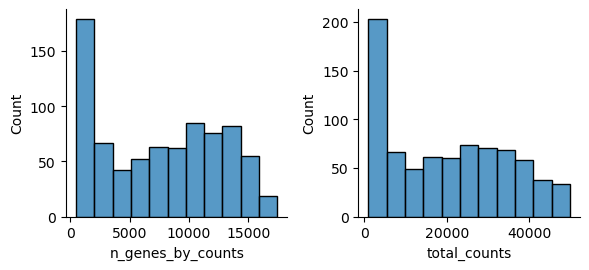

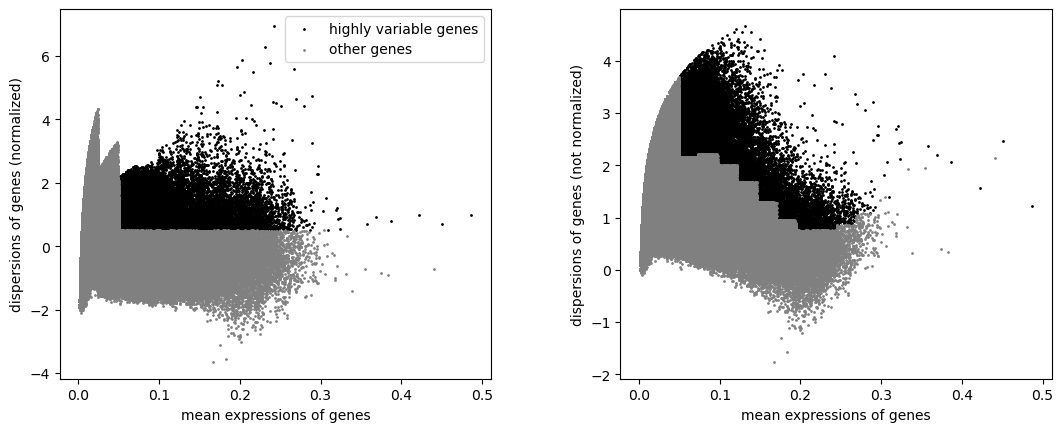

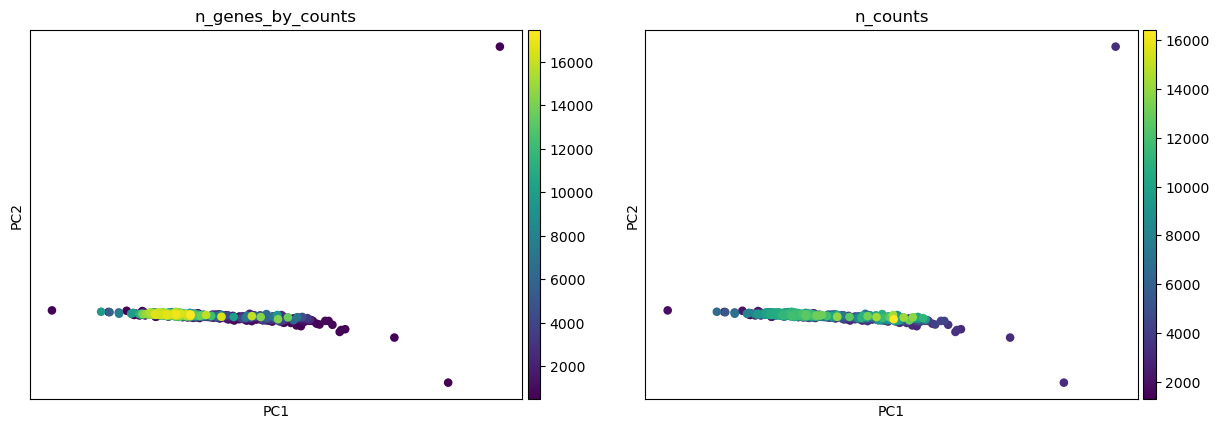

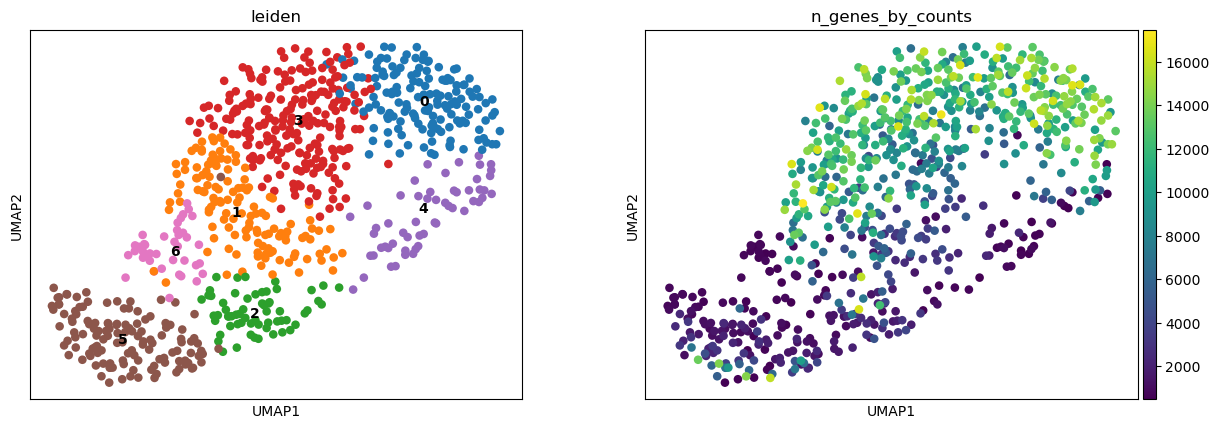

In [52]:
# ATAC QC and Preprocessing
data_processor.atac_qc_filter(
    min_cells_per_peak=MIN_CELLS_PER_PEAK,
    min_peaks_per_cell=MIN_PEAKS_PER_CELL,
    max_peaks_per_cell=MAX_PEAKS_PER_CELL,
    min_total_counts_per_cell=MIN_TOTAL_PEAK_COUNTS,
    max_total_counts_per_cell=MAX_TOTAL_PEAK_COUNTS,
    min_atac_disp=0.5,
    promoter_upstream=1000,
    promoter_downstream=100,
    distal_max=200_000,
    filter_hvgs=True,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc",
    )

Found index: /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/K562_10x_raw/sample_1/fragments.tsv.gz.tbi
['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7']
Fetching Regions...: 100%|█████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 40.82it/s]


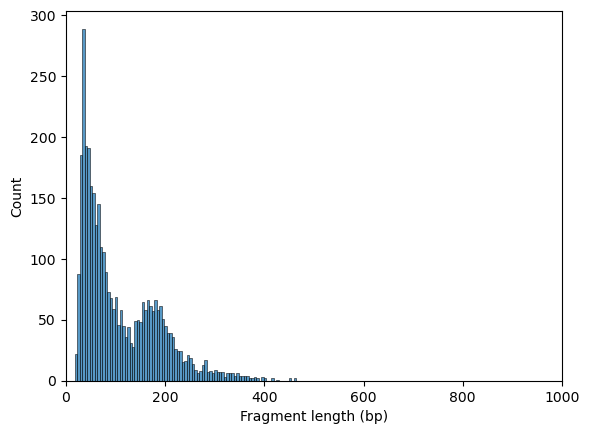

Reading Fragments: 100%|███████████████████████████████████████████| 1000000/1000000 [00:03<00:00, 321004.76it/s]


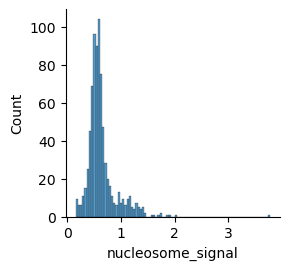

In [53]:
data_processor.nucleosome_signal(
    frag_path=frag_path, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )

Fetching Regions...: 100%|█████████████████████████████████████████████████████| 500/500 [00:08<00:00, 58.02it/s]


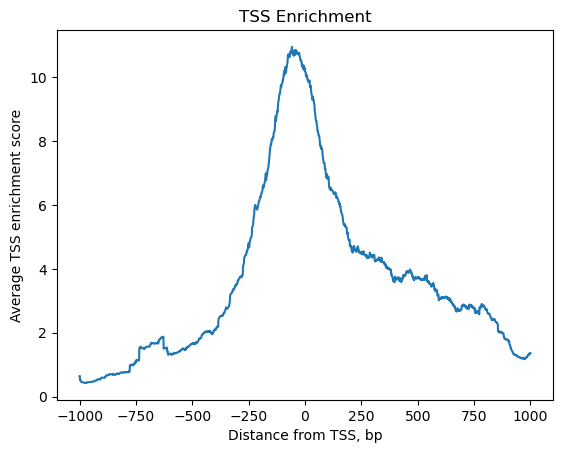

In [54]:
data_processor.tss_enrichment(
    frag_path=frag_path, 
    n_tss=500, 
    extend_upstream=1000, 
    extend_downstream=1000,
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "preprocessing_figures" / "atac_qc"
    )


In [55]:
# Save the processed data
muon_prep.save_processed_data(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR)

  - rna: kept 7320/7321 features after MOFA precheck
  - atac: kept 21145/21145 features after MOFA precheck
  - post-update dims: RNA=7320, ATAC=21145, total=28465



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=621 samples and D=7320 features...
Loaded view='atac' group='group1' with N=621 samples and D=21145 features...




Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Li

... storing 'rna:leiden' as categorical
... storing 'atac:leiden' as categorical
... storing 'rna:tss_chrom' as categorical
... storing 'rna:tss_gene' as categorical
... storing 'rna:interval' as categorical
... storing 'rna:Chromosome' as categorical
... storing 'feature_types' as categorical
... storing 'tss_chrom' as categorical
... storing 'interval' as categorical
... storing 'Chromosome' as categorical


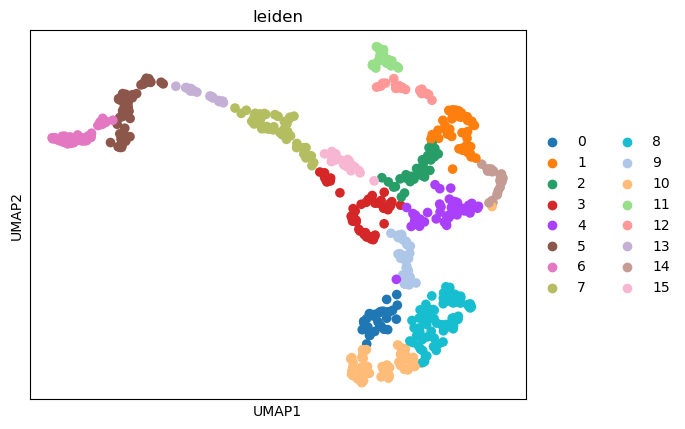

In [56]:
# Integrate the RNA and ATAC modalities using MOFA+
muon_prep.integrate_rna_atac(
    data_processor.mdata, 
    SAMPLE_PROCESSED_DATA_DIR, 
    SAMPLE_NAME, 
    fig_dir=SAMPLE_PROCESSED_DATA_DIR / "integration"
    )

In [57]:
# Create metacells
muon_prep.create_metacells(data_processor.mdata, SAMPLE_PROCESSED_DATA_DIR, hops=2)